<a href="https://colab.research.google.com/github/nataliamelo-dev/analise-dados-brasil/blob/main/analise_vendas_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    categoria   total
0      Moveis  3650.0
1  Tecnologia  8700.0


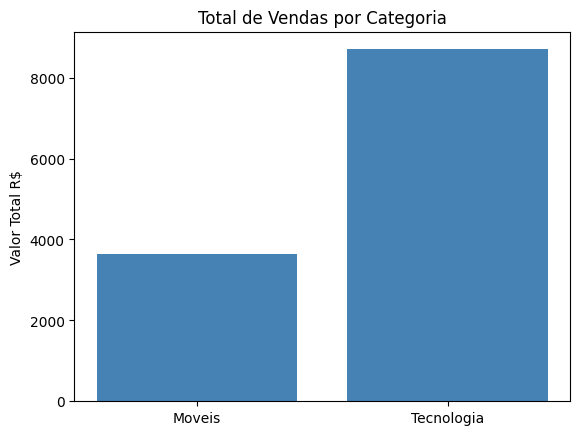

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect(':memory:')

conn.execute('''
CREATE TABLE vendas (
  id INTEGER,
  produto TEXT,
  categoria TEXT,
  valor REAL,
  cidade TEXT
)
''')

conn.execute('''
INSERT INTO vendas VALUES
(1, 'Notebook', 'Tecnologia', 3500, 'Sao Paulo'),
(2, 'Celular', 'Tecnologia', 1800, 'Sorocaba'),
(3, 'Mesa', 'Moveis', 900, 'Campinas'),
(4, 'Cadeira', 'Moveis', 450, 'Sao Paulo'),
(5, 'Tablet', 'Tecnologia', 2200, 'Sorocaba'),
(6, 'Sofá', 'Moveis', 1500, 'Campinas'),
(7, 'Monitor', 'Tecnologia', 1200, 'Sao Paulo'),
(8, 'Armario', 'Moveis', 800, 'Sorocaba')
''')

resultado = pd.read_sql_query('''
SELECT categoria, SUM(valor) as total
FROM vendas
GROUP BY categoria
''', conn)

print(resultado)

plt.bar(resultado['categoria'], resultado['total'], color='steelblue')
plt.title('Total de Vendas por Categoria')
plt.ylabel('Valor Total R$')
plt.show()